In [24]:
# import packages and specify notebook settings

import requests
import os
import h5py
import random

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern']

In [90]:
# modify request function for obtaining data with API keys

api_key = "2b53ab2137136266330440cdef40b53a"
baseUrl = "http://www.tng-project.org/api/" # rerun okay on https instead of http
headers = {"api-key": api_key}

def get(path, params=None):
    
    if "http" in path:
        path = path.replace("http", "https")

    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == "application/json":
        return r.json() # parse json responses automatically

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename
     
    return r

In [3]:
r = get(path=baseUrl)

### Task 1
For `Illustris-1` at $z=0$, get all the fields available for the subhalo with `id=0` and print its total mass and stellar half radius.

In [4]:
r['simulations'][0] # this is Illustris-1

{'name': 'Illustris-1',
 'num_snapshots': 134,
 'url': 'http://www.tng-project.org/api/Illustris-1/'}

For `Illustris-1`, there are a total of $134$ snapshots, with the last one corresponding to $z=0$.

In [5]:
Illustris1_url = r['simulations'][0]['url'] # access name of simulation, in this case Illustris-1
r_Illustris1 = get(path=Illustris1_url) # dictionary containing information keys on Illustris-1

r_Illustris1_snapshots_url = r_Illustris1['snapshots'] # access url for the list of snapshots
r_Illustris1_snapshots = get(path=r_Illustris1_snapshots_url) # list whose elements are dictionaries that contain information on snapshots

r_Illustris1_snapshots_135_url = r_Illustris1_snapshots[-1]['url'] # acess url of target snapshot
r_Illustris1_snapshots_135 = get(path=r_Illustris1_snapshots_135_url) # dictionary containing information on target snapshot

r_Illustris1_snapshots_135_subhalos_url = r_Illustris1_snapshots_135['subhalos'] # access url to the subhalos in the target snapshot
r_Illustris1_snapshots_135_subhalos = get(path=r_Illustris1_snapshots_135_subhalos_url) # dictionary containing information on subhalos contained within the snapshot

r_Illustris1_snapshots_135_subhalos_0_url = r_Illustris1_snapshots_135_subhalos['results'][0]['url'] # access url to the id number of the target subhalo
r_Illustris1_snapshots_135_subhalos_0 = get(path=r_Illustris1_snapshots_135_subhalos_0_url) # dictionary containing information on the target subhalo id


In [6]:
r_Illustris1_snapshots_135_subhalos_0.keys()

dict_keys(['snap', 'id', 'bhmdot', 'cm_x', 'cm_y', 'cm_z', 'gasmetallicity', 'gasmetallicityhalfrad', 'gasmetallicitymaxrad', 'gasmetallicitysfr', 'gasmetallicitysfrweighted', 'pos_x', 'pos_y', 'pos_z', 'halfmassrad', 'halfmassrad_gas', 'halfmassrad_dm', 'halfmassrad_stars', 'halfmassrad_bhs', 'len', 'len_gas', 'len_dm', 'len_stars', 'len_bhs', 'mass', 'mass_gas', 'mass_dm', 'mass_stars', 'mass_bhs', 'massinhalfrad', 'massinhalfrad_gas', 'massinhalfrad_dm', 'massinhalfrad_stars', 'massinhalfrad_bhs', 'massinmaxrad', 'massinmaxrad_gas', 'massinmaxrad_dm', 'massinmaxrad_stars', 'massinmaxrad_bhs', 'massinrad', 'massinrad_gas', 'massinrad_dm', 'massinrad_stars', 'massinrad_bhs', 'sfr', 'sfrinhalfrad', 'sfrinmaxrad', 'sfrinrad', 'spin_x', 'spin_y', 'spin_z', 'starmetallicity', 'starmetallicityhalfrad', 'starmetallicitymaxrad', 'stellarphotometrics_u', 'stellarphotometrics_b', 'stellarphotometrics_v', 'stellarphotometrics_k', 'stellarphotometrics_g', 'stellarphotometrics_r', 'stellarphotome

In [7]:
print("Subhalo Total Mass = " + str(r_Illustris1_snapshots_135_subhalos_0['mass']))
print("Stellar Half Mass Radius = " + str(r_Illustris1_snapshots_135_subhalos_0['halfmassrad_stars']))

Subhalo Total Mass = 22174.8
Stellar Half Mass Radius = 72.0388


### Task 2
For `Illustris-1` at $z=2$, search for all subhalos with total mass $10^{11.9}M_{\odot} < M < 10^{12.1}M_{\odot}$, print the number returned, and the Subfind IDs of the first five results (arbitrarily ordered, you may get different ids).

In [18]:
# for API access, we refer to search query with strings to skip downloading the entire data set and manually querying

# convert mass limits into log solar masses into the group catalog units
mass_min = 10**11.9 / 1e10 * 0.704 
mass_max = 10**12.1 / 1e10 * 0.704

search_query = "?mass__gt=" + str(mass_min) + "&mass__lt=" + str(mass_max)
# print(search_query)

url = "http://www.tng-project.org/api/Illustris-1/snapshots/z=2/subhalos/" + search_query
subhalos = get(url, {"limit":1000})

In [19]:
subhalos['count']

550

In [30]:
random.seed(12345)

ids = [subhalos["results"][i]['id'] for i in [random.randint(0,550) for i in range(5)]]
ids

[129690, 22650, 120560, 126100, 112495]

In [44]:
# peak into one result
get(subhalos['results'][549]['url'])

{'snap': 68,
 'id': 145280,
 'bhmdot': 0.0024824,
 'cm_x': 33074.0,
 'cm_y': 5096.24,
 'cm_z': 51173.0,
 'gasmetallicity': 0.0248884,
 'gasmetallicityhalfrad': 0.0400553,
 'gasmetallicitymaxrad': 0.0158471,
 'gasmetallicitysfr': 0.0154665,
 'gasmetallicitysfrweighted': 0.0179822,
 'pos_x': 33079.5,
 'pos_y': 5083.28,
 'pos_z': 51166.2,
 'halfmassrad': 84.4481,
 'halfmassrad_gas': 60.5688,
 'halfmassrad_dm': 90.6537,
 'halfmassrad_stars': 7.8154,
 'halfmassrad_bhs': 0.0,
 'len': 197190,
 'len_gas': 51290,
 'len_dm': 118451,
 'len_stars': 27448,
 'len_bhs': 1,
 'mass': 59.3229,
 'mass_gas': 5.29092,
 'mass_dm': 52.2246,
 'mass_stars': 1.80132,
 'mass_bhs': 0.006066,
 'massinhalfrad': 2.53746,
 'massinhalfrad_gas': 0.092509,
 'massinhalfrad_dm': 1.53829,
 'massinhalfrad_stars': 0.900598,
 'massinhalfrad_bhs': 0.006066,
 'massinmaxrad': 11.5898,
 'massinmaxrad_gas': 1.22613,
 'massinmaxrad_dm': 8.74518,
 'massinmaxrad_stars': 1.61239,
 'massinmaxrad_bhs': 0.006066,
 'massinrad': 5.95437,
 

### Task 3
For `Illustris-1` at $z=2$, retrieve all fields for five specific Subfind IDs (from previous exercise, saved as `ids`), print the stellar mass and number of star particles in each.

In [54]:
task3_url =  "http://www.tng-project.org/api/Illustris-1/snapshots/z=2/subhalos/"

for id in ids:
#for id in [109974, 110822, 123175, 107743, 95711]:
    task3_subhalo = get(task3_url + str(id))
    print(f"Subfind ID: {id}")
    print("Stellar Mass: " + str(task3_subhalo['mass_stars']))
    print("No. of Stars " + str(task3_subhalo['len_stars']) + "\n")

Subfind ID: 129690
Stellar Mass: 1.7402
No. of Stars 28666

Subfind ID: 22650
Stellar Mass: 0.983083
No. of Stars 17000

Subfind ID: 120560
Stellar Mass: 1.57937
No. of Stars 23485

Subfind ID: 126100
Stellar Mass: 1.98955
No. of Stars 30989

Subfind ID: 112495
Stellar Mass: 2.66028
No. of Stars 39321



### Task 4
For `Illustris-1` at $z=2$, for five specific Subfind IDs (from Task 2 and 3, saved as `ids`), extract and save full cutouts from the snapshot (HDF5 format).

In [69]:
for id in ids:
    url = "http://www.tng-project.org/api/Illustris-1/snapshots/z=2/subhalos/" + str(id) + "/cutout.hdf5"
    saved_filename = get(url)
    print("Subfind ID: " + str(id))
    print(saved_filename)
    

Subfind ID: 129690
cutout_129690.hdf5
Subfind ID: 22650
cutout_22650.hdf5
Subfind ID: 120560
cutout_120560.hdf5
Subfind ID: 126100
cutout_126100.hdf5
Subfind ID: 112495
cutout_112495.hdf5


### Task 5
For `Illustris-1` at $z=2$, for five specific Subfind IDs (from Task 2,3, and 4 saved as `id`), extract and save <i>only star particles</i> from the <i>parent FoF halo</i> of each subhalo.

In [70]:
task5_params = {'stars':'all'}

for id in ids:
    url = "http://www.tng-project.org/api/Illustris-1/snapshots/z=2/subhalos/" + str(id)
    sub = get(url)
    saved_filename = get(sub['cutouts']['parent_halo'], task5_params)
    print(sub['id'], sub['grnr'], saved_filename)

129690 1092 cutout_1092.hdf5
22650 34 cutout_34.hdf5
120560 922 cutout_922.hdf5
126100 1024 cutout_1024.hdf5
112495 785 cutout_785.hdf5


### Task 6
For `Illustris-1` at $z=2$ for Subfind ID `109974`, get a cutout including only the positions and metallicities of stars, and calculate the mean stellar metallicity <i>in solar units</i> within the annuli $3\text{kpc} < r < 5\text{kpc}$ (proper) centered on the fiducial subhalo position.

In [82]:
id = 109974
redshift = 2.0
params = {'stars':'Coordinates,GFM_Metallicity'}

scale_factor = 1 / (1 + redshift)
little_h = 0.704
solar_Z = 0.0127

task6_url = "http://www.tng-project.org/api/Illustris-1/snapshots/z=" + str(redshift) + "/subhalos/" + str(id)
sub = get(task6_url)
saved_filename = get(task6_url + "/cutout.hdf5", params)

with h5py.File(saved_filename) as f:

    dx = f['PartType4']['Coordinates'][:,0] - sub['pos_x']
    dy = f['PartType4']['Coordinates'][:,1] - sub['pos_y']
    dz = f['PartType4']['Coordinates'][:,2] - sub['pos_z']
    metals = f['PartType4']['GFM_Metallicity'][:]

    rr = np.sqrt(dx**2 + dy**2 + dz**2)
    rr *= scale_factor / little_h

    w = np.where((rr >= 3.0) & (rr <= 5))

    print(np.mean(metals[w])/solar_Z)

    

/Users/genebelinario/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1056: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.tng-project.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
/Users/genebelinario/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1056: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.tng-project.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
/Users/genebelinario/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1056: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.tng-project.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.w

0.24839260388077714


### Task 8
For `Illustris-1` at $z=2$, for five specific Subfind IDs (from Task 2,3,4, and 5 saved as `ids`), locate the $z=0$ descendant of each by using the API to walk down the Sublink descendant links.

In [93]:
# use ids variable from the previous tasks
ids = [109974, 110822, 123175, 107743, 95711]
z0_descendants_id = [-1]*len(ids)

for i, id in enumerate(ids):

    start_url = "http://www.tng-project.org/api/Illustris-1/snapshots/68/subhalos/" + str(id)
    sub = get(start_url)

    while sub['desc_sfid'] != -1:
        # request the full subhalo details of the descendant by following the sublink URL
        sub = get(sub['related']['sublink_descendant'])
        if sub['snap'] == 135:
            z0_descendants_id[i] = sub['id']
    
    if z0_descendants_id[i] >= 0:
        print('Descendant of ' + str(id) + " at z=0 is " + str(z0_descendants_id[i]))
    else:
        print('Descendants of ' + str(id) + " not followed to z=0!")

Descendant of 109974 at z=0 is 41092
Descendant of 110822 at z=0 is 338375
Descendant of 123175 at z=0 is 257378
Descendant of 107743 at z=0 is 110568
Descendant of 95711 at z=0 is 260067


### Task 9
For `Illustris-1` at $z=2$ track Subfind ID 109974 to $z=0$, using the API to walk down the Sublink descendant links, and plot the mass evolution of each component (gas, dark matter, stars, and black holes).

/var/folders/z7/s5rym2f96s37ltj5j14bx20w0000gn/T/ipykernel_24930/1464042718.py:20: RuntimeWarning: divide by zero encountered in log10
  mass_logmsun = np.log10(r['mass_'+partType])*1e10/0.704


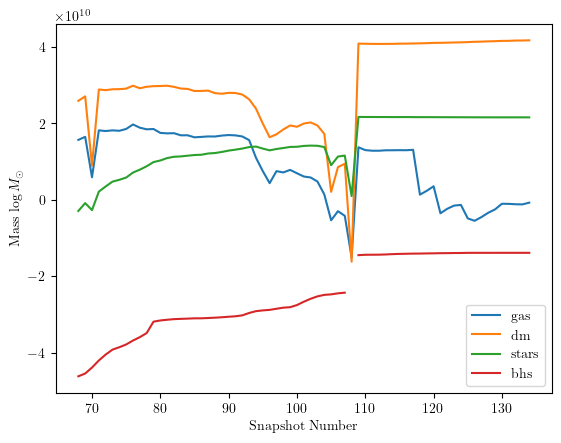

In [100]:
task9_id = 108874
url = "http://www.tng-project.org/api/Illustris-1/snapshots/68/subhalos/" + str(id)

sub = get(url)

# set dict to hold resulting arrays 
fields = ['snap', 'id', 'mass_gas', 'mass_stars', 'mass_dm', 'mass_bhs']
r = {}

for field in fields:
    r[field] = []

while sub['desc_sfid'] != -1:
    for field in fields:
        r[field].append(sub[field])
    
    sub = get(sub['related']['sublink_descendant'])

for partType in ['gas', 'dm', 'stars', 'bhs']:
    mass_logmsun = np.log10(r['mass_'+partType])*1e10/0.704
    plt.plot(r['snap'], mass_logmsun, label=partType)

plt.xlabel("Snapshot Number")
plt.ylabel("Mass $\log M_{\odot}$")
plt.legend(loc="lower right")

plt.show()

### Task 10
For `Illustris-1` at $z=0$, check if pre-rendered mock stellar images exist for five specific Subfind IDs (the descendants from above: 41092, 338375, 257378, 110568, 260067). If so, download and display the PNGs.

### Task 11
Download the entire `Illustris-1` $z=0$ snapshot including only <i>positions, masses, and metallicities of stars</i> (in the form of 512 HDF5 files)